# Learning to solve nonlinear ODE reference tracking problem with robustness

Using [Differentiable predictive control (DPC) method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) to learn robust parametric neural control policy for reference tracking of nonlinear ordinary differential equations (ODE).

Example adopted from: https://apmonitor.com/do/index.php/Main/LevelControl

## NeuroMANCER, eclipse-nn and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [ ]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [ ]:
!pip install eclipse-nn==0.1.4

In [2]:
import torch
import torch.nn as nn
from torch.func import jacrev, vmap
import numpy as np
import math

from neuromancer import Node
import neuromancer.psl as psl
from neuromancer.system import Node, System, SystemPreview
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

In [3]:
from eclipse_nn.LipConstEstimator import LipConstEstimator

## System model 

Lets consider the following system of two connected tanks controlled by a single pump and a two way valve.
The system is a simplified model of a [pumped-storage hydroelectricity](https://en.wikipedia.org/wiki/Pumped-storage_hydroelectricity) which is a type of hydroelectric energy storage used by electric power systems for [load balancing](https://en.wikipedia.org/wiki/Load_balancing_(electrical_power). 

**System schematics**:  
<img src="../figs/two_tank_level.png" width="250">  

**System model**:  
The system dynamics is defined by following nonlinear ordinary differential equations (ODEs):
$$
 \frac{dx_1}{dt} = c_1 (1.0 - v)  p - c_2  \sqrt{x_1}  \\  
 \frac{dx_2}{dt}  = c_1 v p + c_2  \sqrt{x_1} - c_2 \sqrt{x_2}
$$  
With system states $x_1$, and $x_2$ representing liquid levels in tank 1 and 2, respectively. Control actions are pump modulation $p$, and valve opening $v$. The ODE system is parametrized by inlet and outlet valve coefficients $c_1$ and $c_2$, respectively.

**Control ojective**:   
The objective is to control the tank levels into desired reference values by modulating the pump and valve control actions.

System model and image adopted from: https://apmonitor.com/do/index.php/Main/LevelControl

In [4]:
# ground truth system model
gt_model = psl.nonautonomous.TwoTank()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = 0
umax = 1.
xmin = 0
xmax = 1.

# Differentiable Predictive Control 

Next we show how to solve the corresponding parametric optimal control using the [DPC method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) implemented in Neuromancer.

**Schematics of the Differentiable Predictive Control method**:  
<img src="./figs/DPC_simple_method.png" width="600">  

**Neural control policy**:  
The objective of this tutorial is to learn neural control policy $u_k = \pi(x_k, R)$ to control the tank levels by modulating the pump and valve control actions $u_k = [p_k, v_k]$. The policy takes in the measurements of system states $x_k$ at thime $k$ and desired references $R = [r_k, ..., r_{k+N}]$ over pre-defined horizon $N$. This tutorial shows how to construct a DPC policy in scenarios where future references $[r_{k+1}, ..., r_{k+N}]$ are known and where they are unknown, i.e $[r_{k+1},\dots,r_{k+N}]=r_k$.

**Differentiable system model**:  
The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In this example, we compactly represent the system model by ODE equations  $\text{ODESolve}(f(x^i_k, u^i_k))$  describing the governing dynamics of the controlled system.   

**Regularization to enhance robustness**:  
We regularizes the Jacobian of the neural controller or the closed-loop dynamics to enforce robustness. We will discuss the expressions in details shortly.

**Differentiable predictive control problem formulation**:    
We learn the explicit neural control policy by solving the following parametric optimal control problem: 
$$
\begin{align}
&\underset{\theta}{\text{minimize}}     && \sum_{i=1}^m  \Big( \sum_{k=1}^{N-1} Q_x||x^i_k - r^i_k||_2^2  + Q_N||x^i_N - r^i_N||_2^2 + Q_J \mathcal{L}_{\mathrm{rob}}\left(x^i_k,r^i_k\right) \Big) \\
&\text{subject to}    && x^i_{k+1} =  \text{ODESolve}(f(x^i_k, u^i_k)) \\
&                     && u^i_k = \pi_{\theta}(x^i_k, R^i) \\
&                     && 0 \le x^i_k \le 1 \\
&                     && 0 \le u^i_k \le 1 \\
&                     && x^i_0 \sim \mathcal{P}_{x_0} \\
&                     && R^i \sim  \mathcal{P}_R
\end{align}
$$  
The objective function
1. minimizes the reference tracking error $||x^i_k - r^i_k||_2^2$ over pre-defined prediction horizon $N$ weighted by a scalar $Q_x$, including terminal penalty weighted by $Q_N$.
2. adovocates robustness to the control input / trajectory by adding penalty $\mathcal{L}_{\mathrm{rob}}$. 
   
The parametric neural control policy is given by $\pi_{\theta}(x^i_k, R^i)$. The neural control policy is optimized over a problem parameters sampled from the distributions $\mathcal{P}_{x_0}$, and $\mathcal{P}_R$, for state initial conditions, and references, respectively. The parameters $\theta$ are optimized with stochastic gradient descent.

### Two choices for $\mathcal{L}_{\mathrm{rob}}$
We abbreivate $\pi_\theta(x,r)$ to $\pi(x,r)$ for simplicity.

#### 1. Define regularization on the neural controller Jacobian $J(x)$
The **neural controller** Jacobian is
$$
J(x) 
= \frac{\partial \pi}{\partial x}(x,r),
\quad \text{with } u=\pi(x,r).
$$

A robustness-promoting regularizer penalizes the squared Frobenius norm
$$
\mathcal{L}^{NN}_{\mathrm{rob}}(x,r)
= \left\|J(x)\right\|_F^2
= \left\|
\frac{\partial \pi}{\partial x}(x,r)
\right\|_F^2.
$$

In [5]:
def make_jac_node(policy):

    def _jac(x, r):
        # x: [Batch, nx]
        # r: [Batch, nr]

        def single_sample_policy(x_single, r_single):
            out = policy({
                'x': x_single.unsqueeze(0),
                'r': r_single.unsqueeze(0),
            })
            u = out['u'].squeeze(0)
            return u

        # J_pi: [Batch, nu, nx]
        J_pi = vmap(
            lambda xs, rs: jacrev(
                lambda x_: single_sample_policy(x_, rs)
            )(xs)
        )(x, r)

        # Frobenius norm per sample
        j = torch.linalg.norm(J_pi, ord='fro', dim=(-2, -1))
        return j.unsqueeze(-1)

    return Node(_jac,['x', 'r'],['J_norm'],name='jac')


#### 2. Define regularization on the closed-loop Jacobian
The **closed-loop** Jacobian (w.r.t. the state) is
$$
J_{\mathrm{cl}}(x) 
= \frac{\partial}{\partial x}\,F\!\left(x,\,\pi(x,r)\right)
= \underbrace{\frac{\partial F}{\partial x}(x,u)}_{\text{open-loop state sensitivity}}
\;+\;
\underbrace{\frac{\partial F}{\partial u}(x,u)}_{\text{input channel}} \;
\underbrace{\frac{\partial \pi}{\partial x}(x,r)}_{\text{policy sensitivity}},
\quad \text{with } u=\pi(x,r).
$$

A robustness-promoting regularizer penalizes the (squared) Frobenius norm
$$
\mathcal{L}^{cl}_{\mathrm{rob}}(x,r)
= \left\|J_{\mathrm{cl}}(x)\right\|_F^2
= \left\|
\frac{\partial F}{\partial x}(x,u) 
+ \frac{\partial F}{\partial u}(x,u)\,\frac{\partial \pi}{\partial x}(x,r)
\right\|_F^2.
$$

In [6]:
def make_jac_cl_node(policy_node, model_node):
    """
    Optimized Node for Closed-Loop Jacobian Penalty.
    Calculates || J_cl ||_F = || dF/dx + dF/du * dPi/dx ||_F
    """

    def _forward(x, r):
        # x: [Batch, nx], r: [Batch, nr]

        # --- dynamics: x+ = f(x, u) ---
        def func_dynamics(x_single, u_single):
            out = model_node({
                'x': x_single.unsqueeze(0),
                'u': u_single.unsqueeze(0)
            })
            xnext = out.get('x', out.get('X', out.get('x_next')))
            return xnext.squeeze(0)   # [nx]

        # --- policy output for batch ---
        out_u = policy_node({'x': x, 'r': r})
        U = out_u.get('u', out_u.get('U'))   # [Batch, nu]

        # --- J_pi = d(pi)/dx ---
        batch_J_pi = func.vmap(
            lambda xs, rs: func.jacrev(
                lambda x_: (
                    policy_node({
                        'x': x_.unsqueeze(0),
                        'r': rs.unsqueeze(0)
                    })
                    .get('u')
                    .squeeze(0)
                )
            )(xs)
        )(x, r)   # [Batch, nu, nx]

        # --- J_x = d(f)/dx ---
        batch_J_x = func.vmap(
            func.jacrev(func_dynamics, argnums=0)
        )(x, U)   # [Batch, nx, nx]

        # --- J_u = d(f)/du ---
        batch_J_u = func.vmap(
            func.jacrev(func_dynamics, argnums=1)
        )(x, U)   # [Batch, nx, nu]

        # --- closed-loop Jacobian ---
        J_cl = batch_J_x + torch.matmul(batch_J_u, batch_J_pi)

        # --- Frobenius norm ---
        Jcl_norm = torch.linalg.norm(
            J_cl, ord='fro', dim=(-2, -1)
        ).unsqueeze(1)   # [Batch, 1]

        return Jcl_norm

    return Node(_forward, ['x', 'r'], ['Jcl_norm'], name='jac_cl')


## Training dataset generation

For a training dataset we randomly sample initial conditions of states and sequence of admissible reference trajectories over predefined prediction horizon from given distributions $\mathcal{P}_{x_0}$, and $\mathcal{P}_R$, respectively.

In [7]:
nsteps = 30  # prediction horizon
n_samples = 2000    # number of sampled scenarios

#  sampled references for training the policy
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Training dataset
train_data = DictDataset({'x': torch.rand(n_samples, 1, nx),   # sampled initial conditions of states
                          'r': batched_ref}, name='train')

# sampled references for development set
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Development dataset
dev_data = DictDataset({'x': torch.rand(n_samples, 1, nx),    # sampled initial conditions of states
                        'r': batched_ref}, name='dev')

# torch dataloaders
batch_size = 200
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           collate_fn=train_data.collate_fn,
                                           shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=batch_size,
                                         collate_fn=dev_data.collate_fn,
                                         shuffle=False)

## ODE system model

In the following, we instatiate a continous-time system model together with a 4th order Ruge-Kutta numerical integrator.

In [8]:
# white-box ODE model with no-plant model mismatch
two_tank_ode = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank_ode.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank_ode.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

# integrate continuous time ODE
integrator = integrators.RK4(two_tank_ode, h=torch.tensor(ts))   # using 4th order runge kutta integrator

## System model and Control policy in Neuromancer

Here we construct a closed-loop systems as differentiable  computational graphs by connecting the system dynamics model  $x_{k+1} = \text{ODESolve}(f(x_k, u_k))$ with neural control policies $u_k = \pi_{\theta}(x_k, r_k)$ or $u_k = \pi_{\theta}(x_k, R)$, in case future reference is known. Hence we obtain a trainable system architectures: 

1. Without preview of future reference $x_{k+1} = \text{ODESolve}(f(x_k, \pi_{\theta}(x_k, r_k)))$,
2. With preview of future reference $x_{k+1} = \text{ODESolve}(f(x_k, \pi_{\theta}(x_k, R)))$.

Notice how size of input layers differs in case 1 case 2.

We also compare training without regularization term $L_{rob}$, with $L^{NN}_{rob}$ and with $L^{cl}_{rob}$. Therefore, there are in total 6 sets of training. 

In [9]:
# symbolic system model
model = Node(integrator, ['x', 'u'], ['x'], name='model')

#### No preview of future reference + no regularization:

$\pi_\theta : \mathbb{R}^{n_x\times n_r} \mapsto \mathbb{R}^{n_u}$

In [10]:
# neural net control policy with hard control action bounds
net = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=[32, 32],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy = Node(net, ['x', 'r'], ['u'], name='policy')

# closed-loop system model
cl_system = System([policy, model], nsteps=nsteps)
# cl_system.show()

In [11]:
# We define a separate policy NN net_reg so that training does not cover one another
# neural net control policy with hard control action bounds
net_reg = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=[32, 32],
                    nonlin=activations['gelu'], min=umin, max=umax)

policy_reg =  Node(net_reg, ['x', 'r'], ['u'], name='policy_reg')


# node for regularization (jacobian)
jac_cl = make_jac_cl_node(policy_reg, model)  
# only penalize controller Jacobian
jac =  make_jac_node(policy_reg)  


# closed-loop system model
cl_system_reg = System([policy_reg, model, jac_cl], nsteps=nsteps)


# only penalize controller Jacobian
cl_system_reg = System([policy_reg, model, jac], nsteps=nsteps)

#### With preview of future reference + no regularization:

$\pi_\theta : \mathbb{R}^{n_x\times (N+1)\cdot n_r} \mapsto \mathbb{R}^{n_u}$

In [12]:
# neural net control policy with reference preview
net_preview = blocks.MLP_bounds(insize=nx + (nref*(nsteps+1)), outsize=nu, hsizes=[64, 32],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy_with_preview = Node(net_preview, ['x', 'r'], ['u'], name='policy_with_preview')

cl_system_preview = SystemPreview([policy_with_preview, model], name='cl_system_preview',
                nsteps=nsteps, preview_keys_map={'r': ['policy_with_preview']}, # reference preview for neural control policy node
                preview_length={'r': nsteps}, pad_mode='replicate') # replicate last sample in the sequence

## Differentiable Predictive Control objectives and constraints

Here we take advantage of Neuromancer's high level symbolic language to define objective and constraint terms of our optimal control problem. Furthermore, we utilize a penalty method for constraint relaxation.

In [13]:
# variables
x = variable('x')
ref = variable("r")
jcl = variable("Jcl_norm")
j = variable("J_norm")


# objectives
regulation_loss = 5. * ((x == ref) ^ 2)  # target posistion


# constraints
state_lower_bound_penalty = 10.*(x > xmin)
state_upper_bound_penalty = 10.*(x < xmax)
terminal_lower_bound_penalty = 10.*(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = 10.*(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'


constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]

## Differentiable optimal control problems

Here we put things together to construct a differentibale optimal control problems for both cases.



#### Problem without reference preview + no regularization:

In [16]:
# list of constraints and objectives
objectives = [regulation_loss]

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)

# construct constrained optimization problem without reference preview
# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_{k+1})
problem = Problem([cl_system], loss)
# plot computational graph
# problem.show()

#### Problem with reference preview + no regularization:

In [17]:
# construct constrained optimization problem with reference preview
# data (x_k, [r_k, ..., r_{k+N}]) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_{k+1})
problem_with_preview = Problem([cl_system_preview], loss)

## Solve the problem

We solve the problems using stochastic gradient descent over pre-defined training data of sampled parameters.



#### Solving the problem without reference preview +  no regularization:

In [18]:
optimizer = torch.optim.AdamW(problem.parameters(), lr=0.01)
#  Neuromancer trainer
trainer = Trainer(
    problem,
    train_loader, dev_loader,
    optimizer=optimizer,
    epochs=200,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50, 
)
# Train control policy
best_model = trainer.train()
# load best trained model
trainer.model.load_state_dict(best_model)

epoch: 0  train_loss: 3.6474528312683105
epoch: 1  train_loss: 2.519598960876465
epoch: 2  train_loss: 1.4133293628692627
epoch: 3  train_loss: 1.0900377035140991
epoch: 4  train_loss: 0.9042542576789856
epoch: 5  train_loss: 0.825831413269043
epoch: 6  train_loss: 0.7598634362220764
epoch: 7  train_loss: 0.7128928899765015
epoch: 8  train_loss: 0.6851829290390015
epoch: 9  train_loss: 0.669228196144104
epoch: 10  train_loss: 0.6579157710075378
epoch: 11  train_loss: 0.6514989137649536
epoch: 12  train_loss: 0.6460760831832886
epoch: 13  train_loss: 0.6395887136459351
epoch: 14  train_loss: 0.6359283328056335
epoch: 15  train_loss: 0.6315314769744873
epoch: 16  train_loss: 0.6285680532455444
epoch: 17  train_loss: 0.6261957287788391
epoch: 18  train_loss: 0.6232749223709106
epoch: 19  train_loss: 0.6210582852363586
epoch: 20  train_loss: 0.6195982694625854
epoch: 21  train_loss: 0.6207000613212585
epoch: 22  train_loss: 0.6288384199142456
epoch: 23  train_loss: 0.6331365704536438
epoch

<All keys matched successfully>

#### Solving the problem without reference preview + regularization  $L^{NN}_{rob}$: 

In [19]:
# Applying curriculum learning
import copy
# copy it after standard training 
policy_reg = copy.deepcopy(policy)


# penaly on Jacobian
# jac_cl_loss = 1 * (jcl == 0.)^2 
jac_loss = 1 * (j == 0.)^2 


# penalize closed-loop Jacobian 
# jac_cl = make_jac_cl_node(policy_reg, model)  
# penalize controller Jacobian
jac =  make_jac_node(policy_reg)  


# closed-loop system model
# cl_system_reg = System([policy_reg, model, jac_cl], nsteps=nsteps)
# only penalize controller Jacobian
cl_system_reg = System([policy_reg, model, jac], nsteps=nsteps)


# objectives_reg = [regulation_loss, jac_cl_loss]
objectives_reg = [regulation_loss, jac_loss]
loss_reg = PenaltyLoss(objectives_reg, constraints)

problem_reg = Problem([cl_system_reg], loss_reg)

In [20]:
optimizer_reg = torch.optim.AdamW(problem_reg.parameters(), lr=0.01)
trainer_reg = Trainer(
    problem_reg,
    train_loader, dev_loader,
    optimizer=optimizer_reg,
    epochs=100,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50, 
)
# Train control policy
best_model_reg = trainer_reg.train()
# load best trained model
trainer_reg.model.load_state_dict(best_model_reg)

C:\Users\22384\OneDrive - purdue.edu\Purdue\Research\ECLipsE_package_application\neuromancer\src\neuromancer\constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 30, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0  train_loss: 24.505046844482422
epoch: 1  train_loss: 4.087012767791748
epoch: 2  train_loss: 1.9043632745742798
epoch: 3  train_loss: 1.641195297241211
epoch: 4  train_loss: 1.5607233047485352
epoch: 5  train_loss: 1.5342776775360107
epoch: 6  train_loss: 1.515474557876587
epoch: 7  train_loss: 1.5097296237945557
epoch: 8  train_loss: 1.5032302141189575
epoch: 9  train_loss: 1.4968078136444092
epoch: 10  train_loss: 1.4899013042449951
epoch: 11  train_loss: 1.4833018779754639
epoch: 12  train_loss: 1.4772472381591797
epoch: 13  train_loss: 1.4710588455200195
epoch: 14  train_loss: 1.4659860134124756
epoch: 15  train_loss: 1.4619849920272827
epoch: 16  train_loss: 1.4597527980804443
epoch: 17  train_loss: 1.457680344581604
epoch: 18  train_loss: 1.4556630849838257
epoch: 19  train_loss: 1.4541690349578857
epoch: 20  train_loss: 1.4524409770965576
epoch: 21  train_loss: 1.4505937099456787
epoch: 22  train_loss: 1.4495909214019775
epoch: 23  train_loss: 1.4479377269744873
epoch:

<All keys matched successfully>

#### Solving the problem with reference preview + no regularization:

In [21]:
optimizer_with_preview = torch.optim.Adam(problem_with_preview.parameters(), lr=0.01, weight_decay=0.002)
trainer_with_preview = Trainer(
        problem_with_preview,
        train_loader, dev_loader,
        optimizer=optimizer_with_preview,
        epochs=200,
        train_metric='train_loss',
        eval_metric='dev_loss',
        warmup=50,
    )
# Train control policy with reference preview 
best_model_preview = trainer_with_preview.train()
# Load best model with reference preview
trainer_with_preview.model.load_state_dict(best_model_preview)

epoch: 0  train_loss: 3.0518858432769775
epoch: 1  train_loss: 2.0284018516540527
epoch: 2  train_loss: 1.56467604637146
epoch: 3  train_loss: 1.32881760597229
epoch: 4  train_loss: 1.1616073846817017
epoch: 5  train_loss: 1.106968879699707
epoch: 6  train_loss: 1.0258214473724365
epoch: 7  train_loss: 0.9507526159286499
epoch: 8  train_loss: 0.9243541955947876
epoch: 9  train_loss: 0.9297019839286804
epoch: 10  train_loss: 0.9161580801010132
epoch: 11  train_loss: 0.856555163860321
epoch: 12  train_loss: 0.84270840883255
epoch: 13  train_loss: 0.8672882914543152
epoch: 14  train_loss: 0.8285149335861206
epoch: 15  train_loss: 0.7824068665504456
epoch: 16  train_loss: 0.7557229995727539
epoch: 17  train_loss: 0.7540634870529175
epoch: 18  train_loss: 0.7485166788101196
epoch: 19  train_loss: 0.7345578074455261
epoch: 20  train_loss: 0.7517527341842651
epoch: 21  train_loss: 0.748691201210022
epoch: 22  train_loss: 0.7160893082618713
epoch: 23  train_loss: 0.7474650144577026
epoch: 24  

<All keys matched successfully>

#### Solving the problem with reference preview + regularization  $L^{NN}_{rob}$:

In [34]:
# Applying curriculum learning
import copy
# copy it after standard training 
policy_pre_reg = copy.deepcopy(policy_with_preview)


# penaly on Jacobian
# jac_cl_loss = 1 * (jcl == 0.)^2 
jac_loss = 1 * (j == 0.)^2 


# node for regularization (jacobian)
# jac_pre_cl = make_jac_cl_node(policy_pre_reg, model)  
# only penalize controller Jacobian
jac_pre =  make_jac_node(policy_pre_reg)  

'''
# closed-loop system model
cl_system_pre_reg = SystemPreview(
    [policy_pre_reg, model, jac_pre_cl],
    name='cl_system_pre_reg',
    nsteps=nsteps,
    preview_keys_map={
        'r': ['policy_with_preview', 'jac_cl']  # ← NODE NAMES
    },
    preview_length={'r': nsteps},
    pad_mode='replicate'
)

'''
# penalize controller Jacobian
cl_system_pre_reg = SystemPreview(
    [policy_pre_reg, model, jac_pre],
    name='cl_system_pre_reg',
    nsteps=nsteps,
    preview_keys_map={
        'r': ['policy_with_preview', 'jac']  # ← NODE NAMES
    },
    preview_length={'r': nsteps},
    pad_mode='replicate'
)



objectives_pre_reg = [regulation_loss, jac_loss]
# objectives_pre_reg = [regulation_loss, jac_cl_loss]
loss_pre_reg = PenaltyLoss(objectives_pre_reg, constraints)

problem_pre_reg = Problem([cl_system_pre_reg], loss_pre_reg)

In [35]:
optimizer_pre_reg = torch.optim.AdamW(problem_pre_reg.parameters(), lr=0.01)
trainer_pre_reg = Trainer(
    problem_pre_reg,
    train_loader, dev_loader,
    optimizer=optimizer_pre_reg,
    epochs=100,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50, 
)
# Train control policy
best_model_pre_reg = trainer_pre_reg.train()
# load best trained model
trainer_pre_reg.model.load_state_dict(best_model_pre_reg)

epoch: 0  train_loss: 4.092559814453125
epoch: 1  train_loss: 1.6157957315444946
epoch: 2  train_loss: 1.49454665184021
epoch: 3  train_loss: 1.447321891784668
epoch: 4  train_loss: 1.440611481666565
epoch: 5  train_loss: 1.4544637203216553
epoch: 6  train_loss: 1.4537454843521118
epoch: 7  train_loss: 1.4545633792877197
epoch: 8  train_loss: 1.4532873630523682
epoch: 9  train_loss: 1.4312279224395752
epoch: 10  train_loss: 1.4326950311660767
epoch: 11  train_loss: 1.435462236404419
epoch: 12  train_loss: 1.4410970211029053
epoch: 13  train_loss: 1.4609489440917969
epoch: 14  train_loss: 1.4412434101104736
epoch: 15  train_loss: 1.4281138181686401
epoch: 16  train_loss: 1.438521385192871
epoch: 17  train_loss: 1.4438238143920898
epoch: 18  train_loss: 1.4337167739868164
epoch: 19  train_loss: 1.42569899559021
epoch: 20  train_loss: 1.4287588596343994
epoch: 21  train_loss: 1.4372928142547607
epoch: 22  train_loss: 1.444878339767456
epoch: 23  train_loss: 1.4371391534805298
epoch: 24  t

<All keys matched successfully>

In [36]:
torch.save(trainer_pre_reg.model.state_dict(), 'policy_pre_reg_paras.pt')

# Evaluate best model on a system rollout

In [37]:
# Creating the test data
nsteps = 1000
step_length = 250
# generate reference
np_refs = psl.signals.step(nsteps + 1, 1, min=xmin, max=xmax, randsteps=4, rng=np.random.default_rng(20))
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
# generate initial data for closed loop simulation
data = {'x': torch.rand(1, 1, nx, dtype=torch.float32),
        'r': torch_ref}

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])

## Evaluation of best model without reference preview

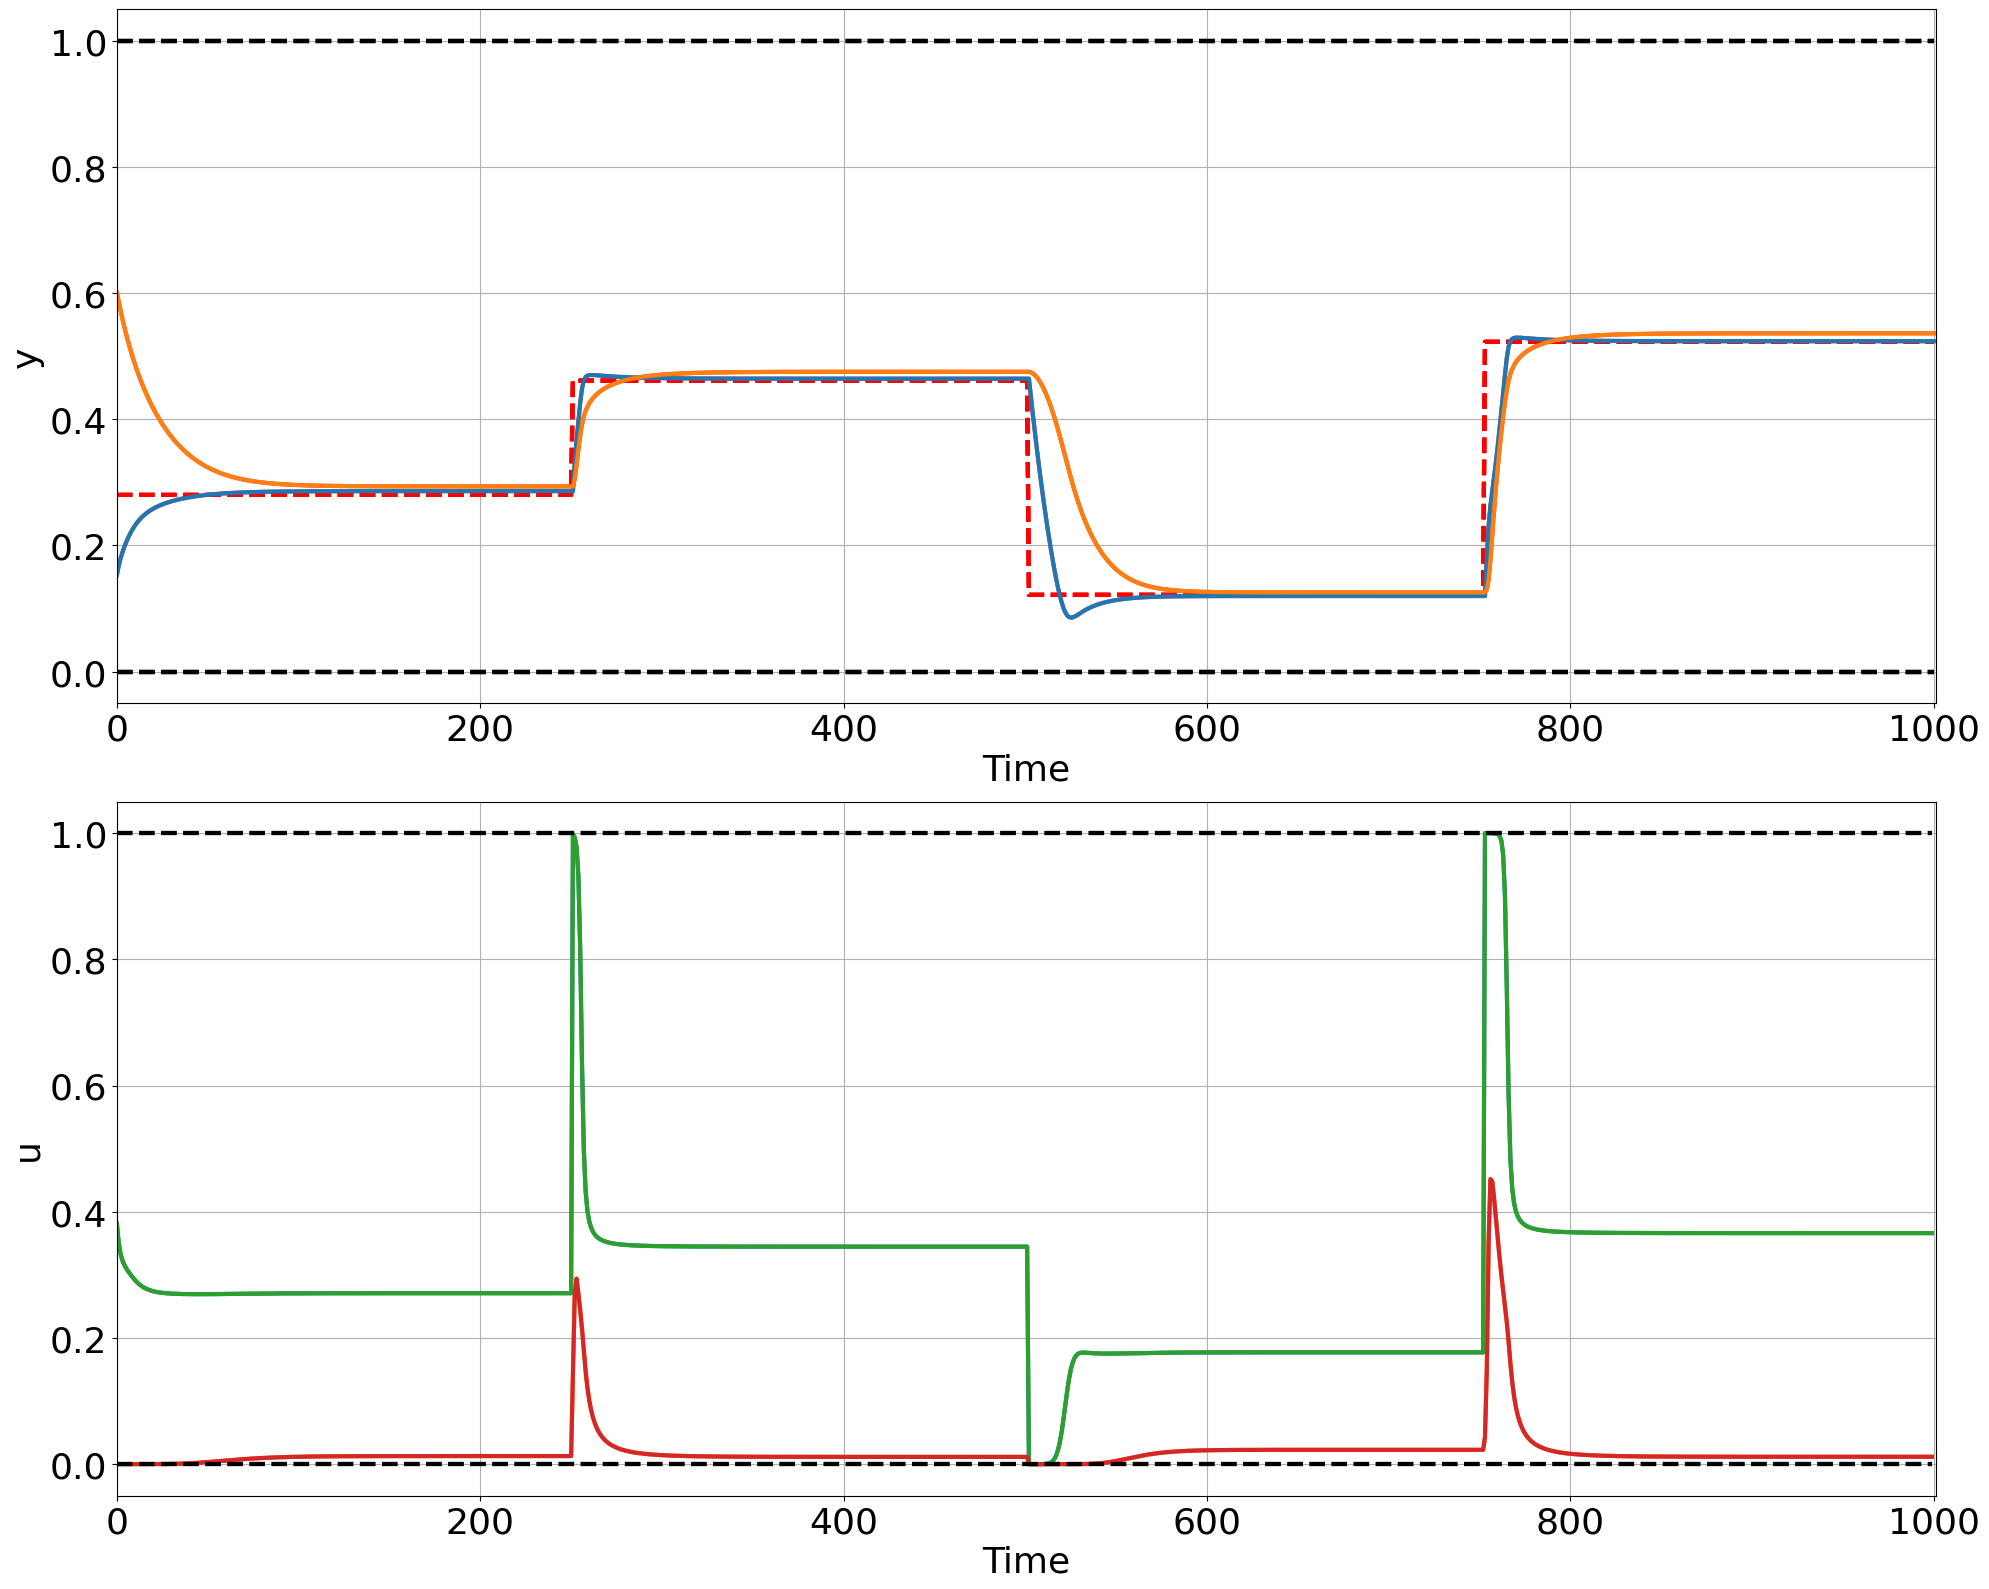

<Figure size 640x480 with 0 Axes>

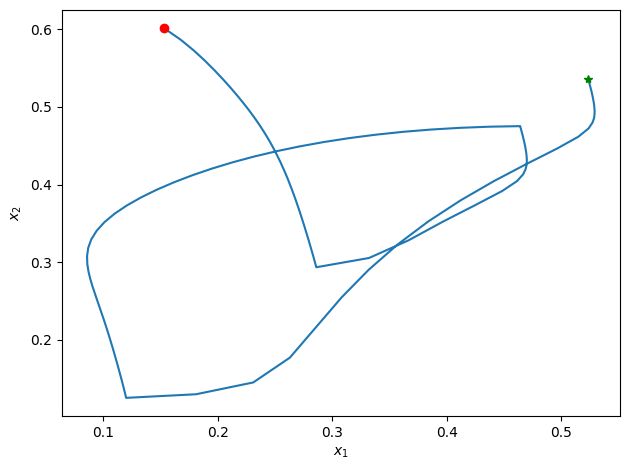

<Figure size 640x480 with 0 Axes>

In [38]:
cl_system.nsteps = nsteps
# perform closed-loop simulation
trajectories = cl_system(data)
# plot closed loop trajectories
pltCL(Y=trajectories['x'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax,
      figname='cl.png')
# plot phase portrait
pltPhase(X=trajectories['x'].detach().reshape(nsteps + 1, nx),
         figname='phase.png')

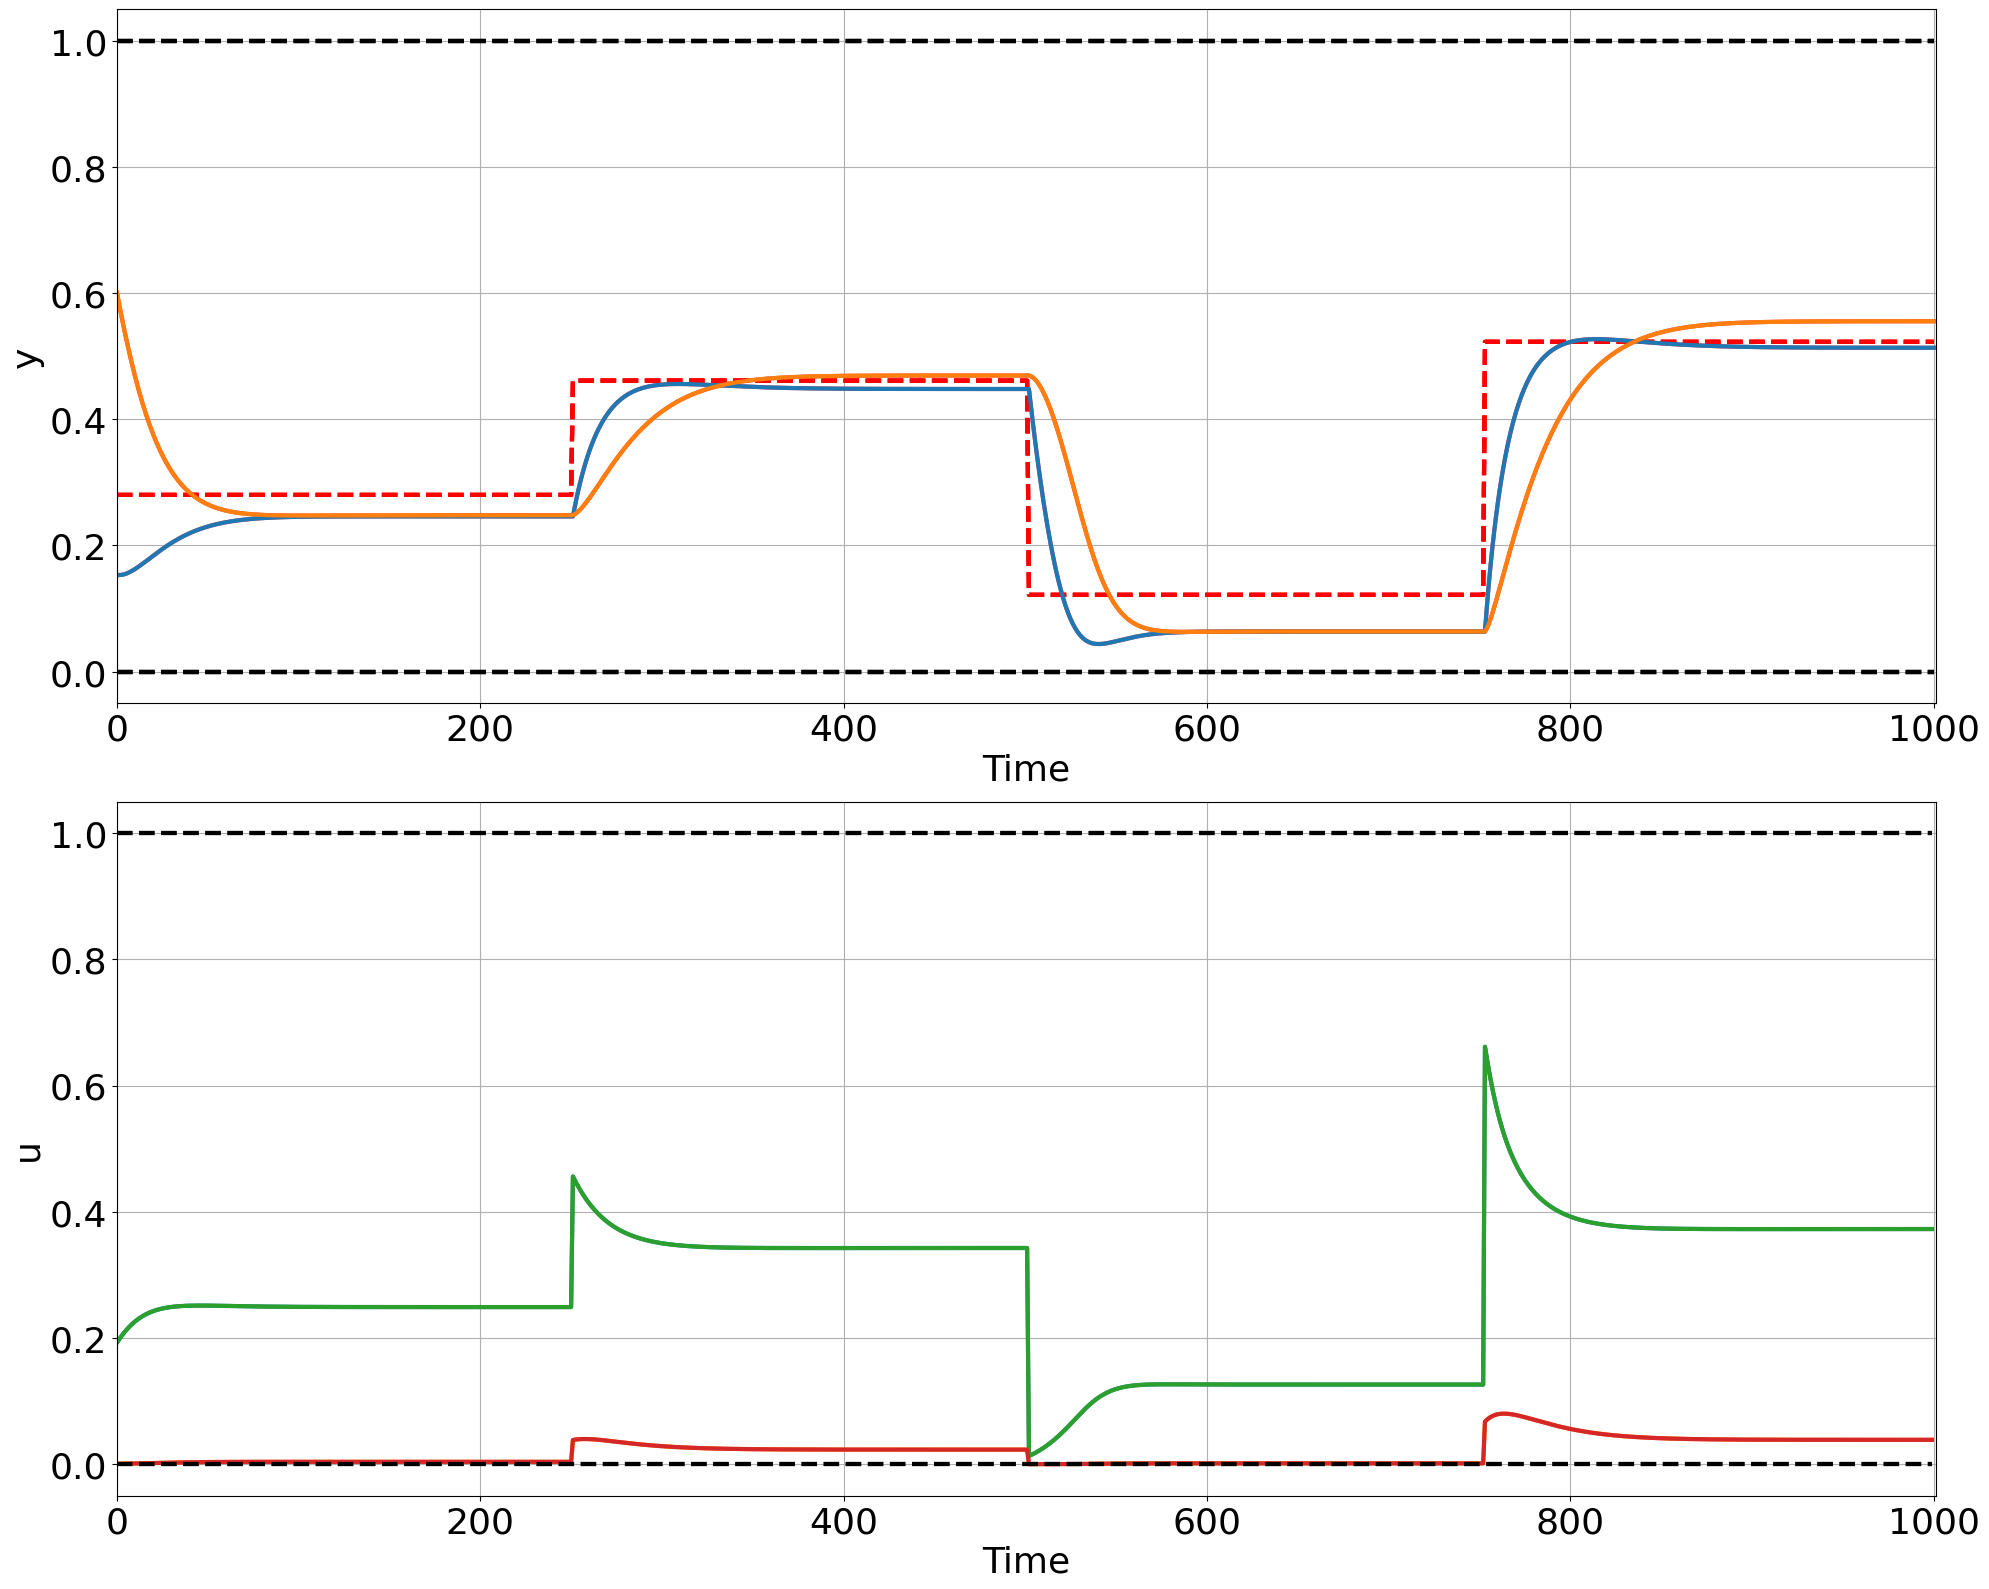

<Figure size 640x480 with 0 Axes>

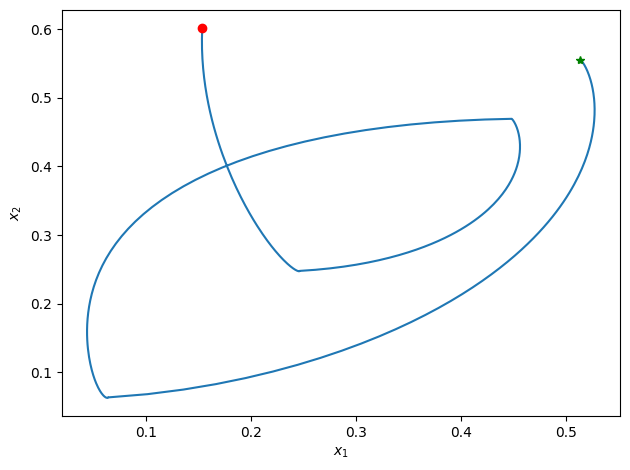

<Figure size 640x480 with 0 Axes>

In [39]:
# Applying curriculum learning
cl_system_reg.nsteps = nsteps
# perform closed-loop simulation
trajectories = cl_system_reg(data)
# plot closed loop trajectories
pltCL(Y=trajectories['x'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax,
      figname='cl.png')
# plot phase portrait
pltPhase(X=trajectories['x'].detach().reshape(nsteps + 1, nx),
         figname='phase.png')

## Evaluation of best model with reference preview

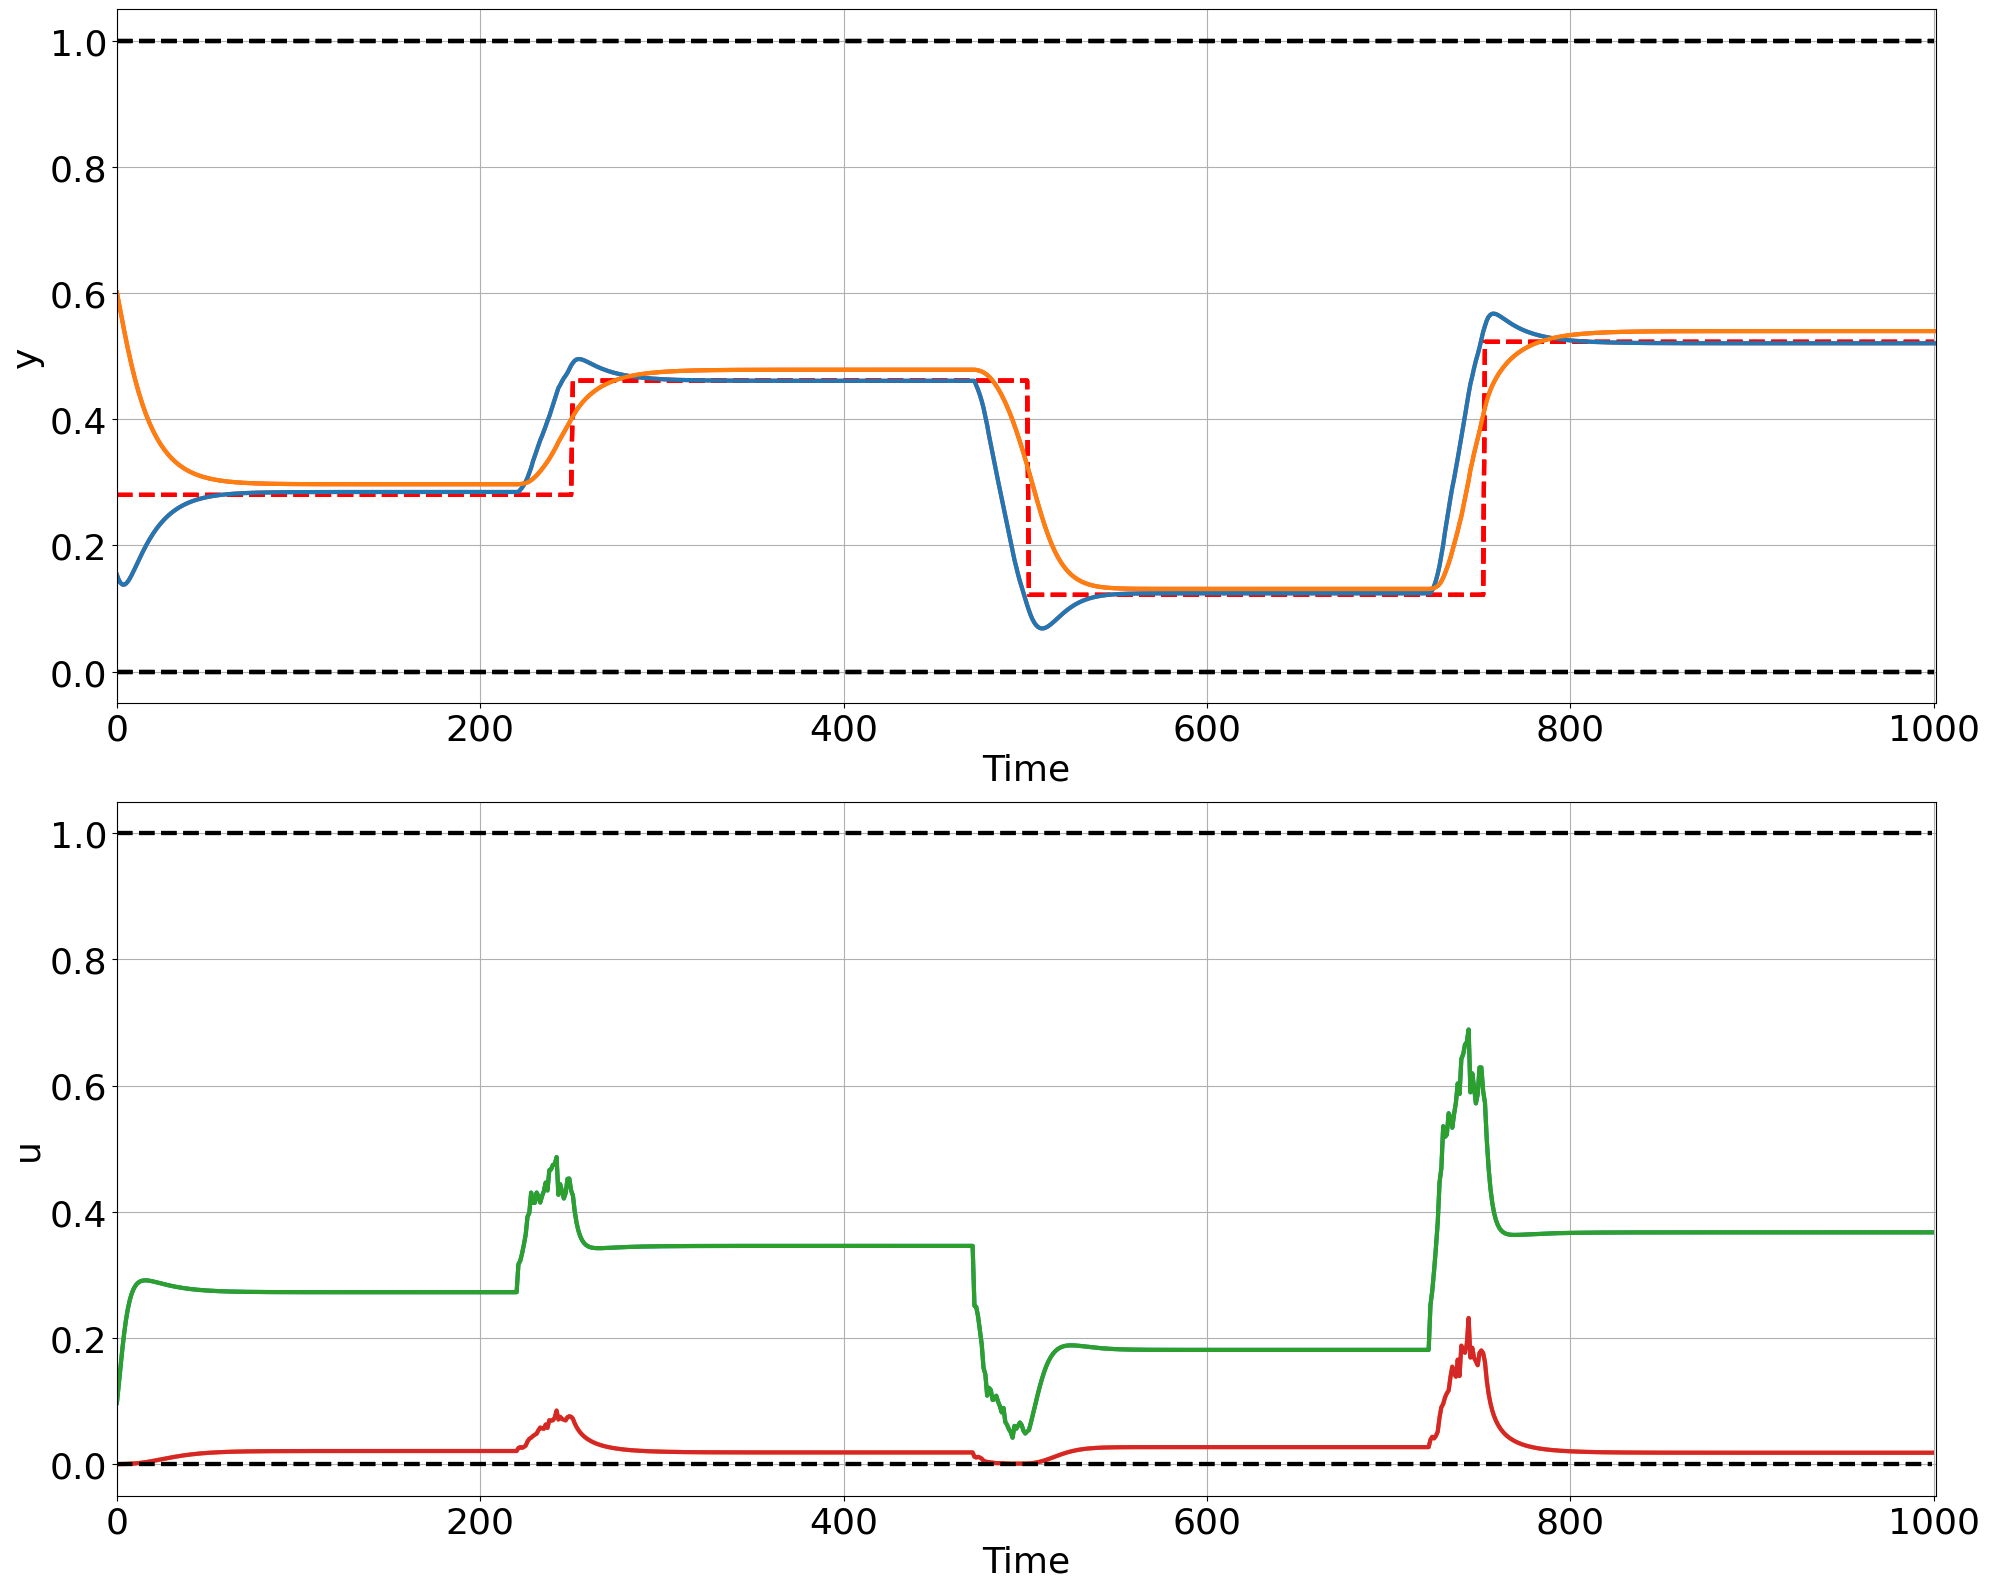

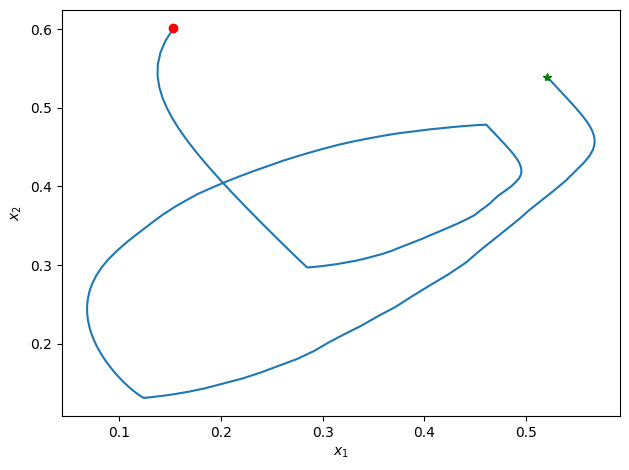

In [40]:
# closed-loop simulation with reference preview
cl_system_preview.nsteps = nsteps
trajectories_with_preview = cl_system_preview(data)
pltCL(Y=trajectories_with_preview['x'].detach().reshape(nsteps + 1, nx),
        R=trajectories_with_preview['r'].detach().reshape(nsteps + 1, nref),
        U=trajectories_with_preview['u'].detach().reshape(nsteps, nu),
        Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)
pltPhase(X=trajectories_with_preview['x'].detach().reshape(nsteps + 1, nx))

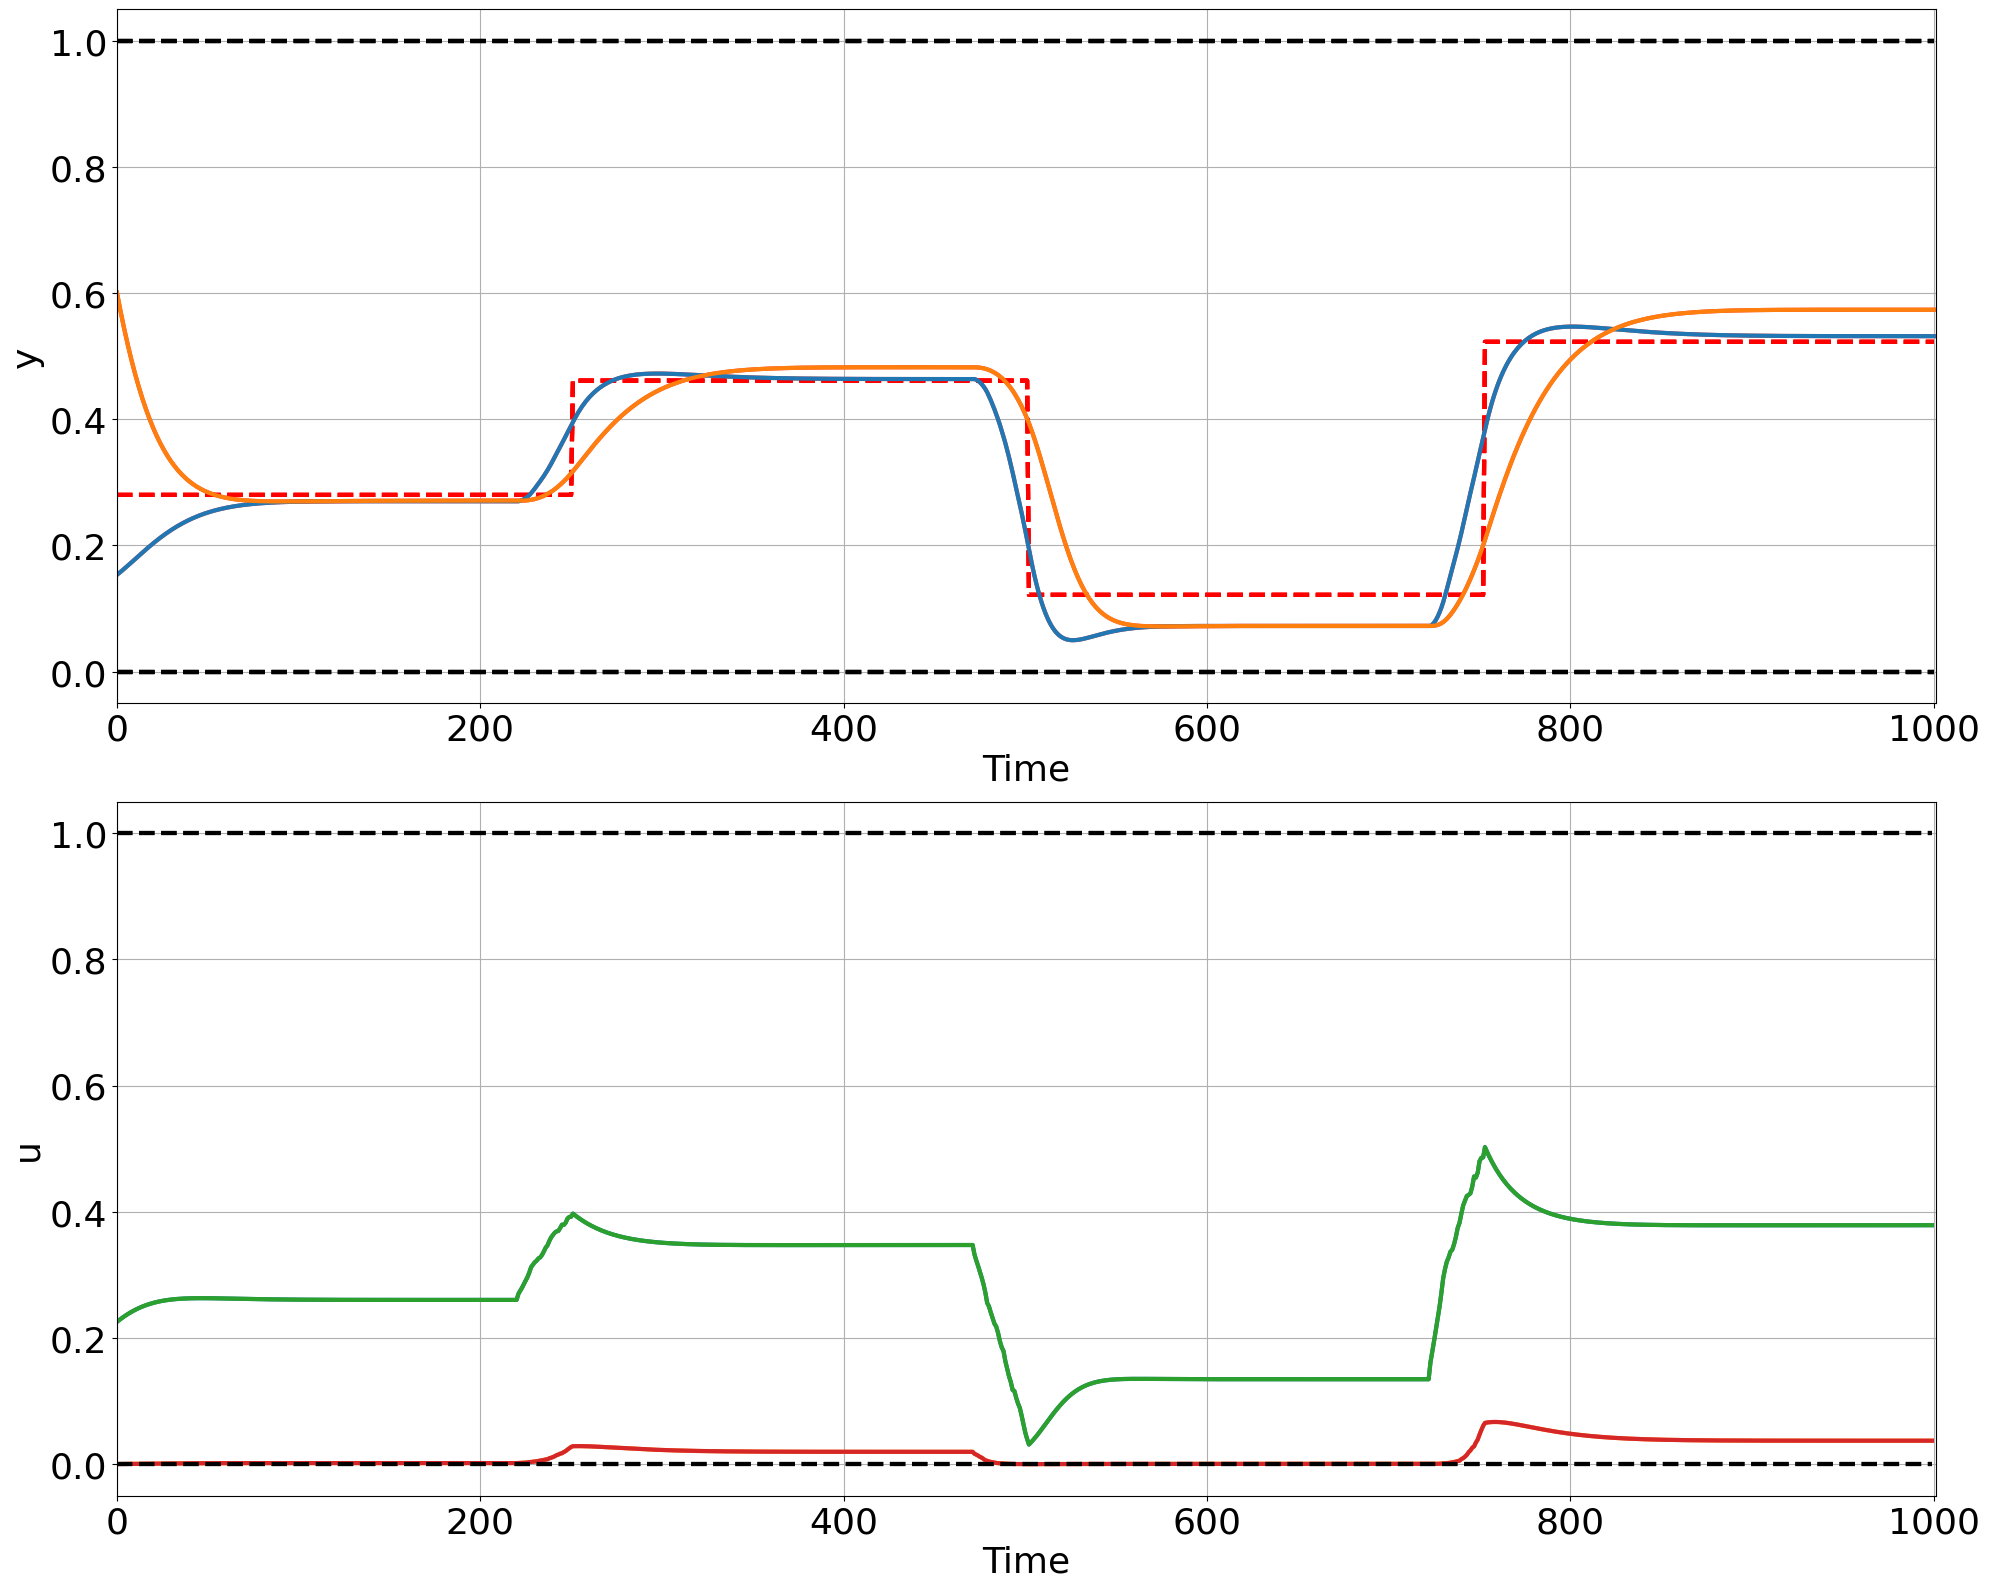

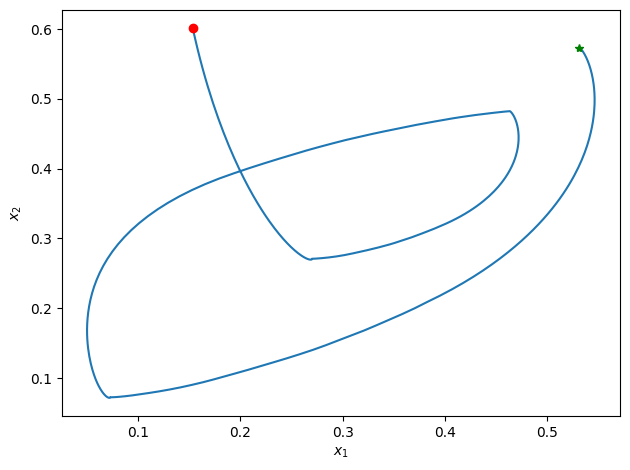

In [41]:
# closed-loop simulation with reference preview
cl_system_pre_reg.nsteps = nsteps
trajectories_with_preview_reg = cl_system_pre_reg(data)
pltCL(Y=trajectories_with_preview_reg['x'].detach().reshape(nsteps + 1, nx),
        R=trajectories_with_preview_reg['r'].detach().reshape(nsteps + 1, nref),
        U=trajectories_with_preview_reg['u'].detach().reshape(nsteps, nu),
        Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)
pltPhase(X=trajectories_with_preview_reg['x'].detach().reshape(nsteps + 1, nx))

## Testing the robustness of learned model by estimating Lipschitz constant of $\pi_\theta(x,r)$

In [42]:
# Some helper function to load the saved model paramters.
import re
import torch
import torch.nn as nn
from collections import defaultdict

def neuromancer_state_to_fnn(paras, group_hint=None, activation_cls=nn.ReLU):
    """
    Convert a Neuromancer-style state_dict (paras) into a standard PyTorch FNN.
    - Groups linear layers by prefix and finds a consistent chain where
      out_features(prev) == in_features(next).
    - Chooses the longest valid chain, or prefer one via `group_hint` substring.
    - Uses `activation_cls` between linears (no activation after last).
    Returns:
        nn.Sequential
    """
    # 0) normalize keys (strip 'module.' if present)
    if any(k.startswith("module.") for k in paras.keys()):
        paras = {k.replace("module.", "", 1): v for k, v in paras.items()}

    # 1) collect linear layers by group prefix and index
    pat = re.compile(r"^(?P<prefix>.*?linear\.)"
                     r"(?P<idx>\d+)"
                     r"(?:\.linear)?\.(?P<wb>weight|bias)$")
    groups = defaultdict(lambda: defaultdict(dict))
    for k, v in paras.items():
        m = pat.match(k)
        if m:
            prefix = m.group("prefix")
            idx = int(m.group("idx"))
            wb = m.group("wb")
            groups[prefix][idx][wb] = v

    if not groups:
        raise ValueError("No linear layers found in the provided state dict.")

    # 2) optional preference by hint
    group_items = list(groups.items())
    if group_hint:
        group_items.sort(key=lambda kv: (group_hint in kv[0], len(kv[0])), reverse=True)

    # 3) build a maximal dimensionally-consistent chain per group
    def build_chain(prefix, layers_dict):
        idxs = sorted(layers_dict.keys())
        layers = [(i, layers_dict[i]['weight'], layers_dict[i].get('bias', None))
                  for i in idxs if 'weight' in layers_dict[i]]
        if not layers:
            return None

        best, cur = [], [layers[0]]
        for prev, nxt in zip(layers, layers[1:]):
            _, Wp, _ = prev
            _, Wn, _ = nxt
            if Wp.shape[0] == Wn.shape[1]:
                cur.append(nxt)
            else:
                if len(cur) > len(best): best = cur
                cur = [nxt]
        if len(cur) > len(best): best = cur
        if not best:
            return None

        in_dim = best[0][1].shape[1]
        dims = [in_dim] + [b[1].shape[0] for b in best]
        weights = [b[1] for b in best]
        biases  = [b[2] for b in best]
        return {'prefix': prefix, 'idxs': [b[0] for b in best],
                'dims': dims, 'weights': weights, 'biases': biases}

    candidates = [ch for prefix, d in group_items if (ch := build_chain(prefix, d))]
    if not candidates:
        raise ValueError("Could not form a consistent linear chain. "
                         f"Found groups: {list(groups.keys())}. "
                         "Try passing group_hint='nodes.0.nodes.0.callable.linear.'")

    candidates.sort(key=lambda c: (len(c['weights']), len(c['dims']), len(c['prefix'])), reverse=True)
    chosen = candidates[0]

    # diagnostics
    print("[Converter] Chosen group:", chosen['prefix'])
    print("[Converter] Layer indices:", chosen['idxs'])
    print("[Converter] Dims:", " -> ".join(map(str, chosen['dims'])))

    # 4) build FNN and load weights
    dims = chosen['dims']
    layers = []
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:
            layers.append(activation_cls())
    model = nn.Sequential(*layers)

    with torch.no_grad():
        wi = 0
        for m in model:
            if isinstance(m, nn.Linear):
                W = chosen['weights'][wi]
                b = chosen['biases'][wi]
                if m.weight.shape != W.shape:
                    raise RuntimeError(f"Weight shape mismatch: {m.weight.shape} vs {W.shape} at layer {wi}")
                m.weight.copy_(W)
                if b is not None:
                    if m.bias.shape != b.shape:
                        raise RuntimeError(f"Bias shape mismatch: {m.bias.shape} vs {b.shape} at layer {wi}")
                    m.bias.copy_(b)
                wi += 1

    model.eval()
    return model


In [43]:
paras_reg = torch.load('policy_reg_paras.pt')
seq_reg = neuromancer_state_to_fnn(paras_reg)

[Converter] Chosen group: nodes.0.nodes.0.callable.linear.
[Converter] Layer indices: [0, 1, 2]
[Converter] Dims: 4 -> 32 -> 32 -> 2


In [44]:
est_reg = LipConstEstimator(model=seq_reg)
# est.model_review()
lip_reg = est_reg.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller is {lip_reg}")

The Lipschitz estimate for controller is 10.775456931902395


In [45]:
paras_with_preview_reg = torch.load('policy_with_preview_reg_paras.pt')
seq_with_preview_reg = neuromancer_state_to_fnn(paras_with_preview_reg)

[Converter] Chosen group: nodes.0.nodes.0.callable.linear.
[Converter] Layer indices: [0, 1, 2]
[Converter] Dims: 64 -> 64 -> 32 -> 2


In [46]:
est_with_preview_reg = LipConstEstimator(model=seq_with_preview_reg)
# est.model_review()
lip_with_preview_reg = est_with_preview_reg.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller is {lip_with_preview_reg}")

The Lipschitz estimate for controller is 4.898673568006278


In [47]:
# directly extract weights from the model
import re

def extract_eclipse_tensors(model_dict, device='cpu'):
    """
    Extracts weights from a Neuromancer state_dict as a list of Double-Precision Tensors
    suitable for eclipse-nn input.
    
    Args:
        model_dict (dict): The state_dict from best_model (e.g., best_model_reg)
        device (str): 'cpu' or 'cuda'.
    
    Returns:
        weights (list of torch.Tensor): [W1, W2, ..., Wn] in float64
    """
    layer_weights = {}
    
    # Regex to capture layer index from keys like 'nodes.0...linear.0.weight'
    pattern = re.compile(r"linear\.(\d+)\.(weight)")
    
    for key, val in model_dict.items():
        match = pattern.search(key)
        if match:
            layer_idx = int(match.group(1))
            
            # CRITICAL FIX: Add .double() to match eclipse-nn's float64 requirement
            w_tensor = val.detach().clone().double().to(device)
            
            layer_weights[layer_idx] = w_tensor

    # Sort keys to ensure order: Layer 0 -> Layer 1 -> ...
    sorted_indices = sorted(layer_weights.keys())
    
    weights_list = [layer_weights[i] for i in sorted_indices]
    
    print(f"Extracted {len(weights_list)} weight matrices (float64).")
    return weights_list

In [48]:
# extract weights for Lipschitz estimates
Ws = extract_eclipse_tensors(best_model, device='cpu')
est = LipConstEstimator(weights=Ws)
# est.model_review()
lip = est.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller from standard training without reference is {lip}")

Extracted 3 weight matrices (float64).
The Lipschitz estimate for controller from standard training without reference is 19.982431009323083


In [49]:
# extract weights for Lipschitz estimates
Ws_reg = extract_eclipse_tensors(best_model_reg, device='cpu')
est_reg = LipConstEstimator(weights=Ws_reg)
# est.model_review()
lip_reg = est_reg.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller from regularized training without reference is {lip_reg}")

Extracted 3 weight matrices (float64).
The Lipschitz estimate for controller from regularized training without reference is 17.344948950065657


In [ ]:
# extract weights for Lipschitz estimates
Ws_preview = extract_eclipse_tensors(best_model_preview, device='cpu')
est_preview = LipConstEstimator(weights=Ws_preview)
# est.model_review()
lip_preview = est_preview.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller from standard training with reference is {lip_preview}")

Extracted 3 weight matrices (float64).


### Warning!!! Something weird here. not matching the estimates above and the estimates increases after regularization

In [ ]:
# extract weights for Lipschitz estimates
Ws_pre_reg = extract_eclipse_tensors(best_model_pre_reg, device='cpu')
est_pre_reg = LipConstEstimator(weights=Ws_pre_reg)
# est.model_review()
lip_pre_reg = est_pre_reg.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller from regularized training with reference is {lip_pre_reg}")

## Conclusions

In both scenarios, the trained control policies effectively address the reference-tracking problem without violating state or input constraints. Furthermore, incorporating a preview window of future reference signals highlights the predictive capabilities of the trained controller, enabling aticipatory control decisions. 

Adding regularization enables smoother thus more robust control input and trajectory in sacrifice of certain tracking performance. The Lipschitz estimates of $\pi_\theta(x,r)$ work as a good indicator of the robustness as the smaller Lipschitz estimates correspond to the smoother results.